# Customer Segmentation Analysis

## Oasis Infobyte Data Analytics Internship — Task 2

### Objective

The objective of this project is to segment an e-commerce companys customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

The analysis aims to identify distinct customer groups and provide targeted marketing recommendations for each segment.

### Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [5]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [7]:
df = pd.read_excel("Online Retail.xlsx")

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
# Check missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", df.shape[0])

Rows after removing missing CustomerID: 406829


In [14]:
# Check and remove duplicate rows

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Duplicate rows: 5225
Rows after removing duplicates: 401604


In [15]:
# Remove cancelled/returned transactions and invalid quantities/prices

df = df[
    (~df["InvoiceNo"].astype(str).str.startswith("C")) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 392692


In [16]:
# Calculate total purchase value for each transaction

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
# Check the cleaned dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum())

Rows: 392692
Columns: 9

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


In [18]:
# Descriptive statistics

print("Average Purchase Value:", df["TotalAmount"].mean())
print("Average Quantity per Transaction:", df["Quantity"].mean())
print("Total Revenue:", df["TotalAmount"].sum())
print("Number of Unique Customers:", df["CustomerID"].nunique())
print("Number of Transactions:", df["InvoiceNo"].nunique())

Average Purchase Value: 22.6314997351614
Average Quantity per Transaction: 13.1197019547126
Total Revenue: 8887208.894
Number of Unique Customers: 4338
Number of Transactions: 18532


In [19]:
# Create RFM features

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [20]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [21]:
# Standardise RFM features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


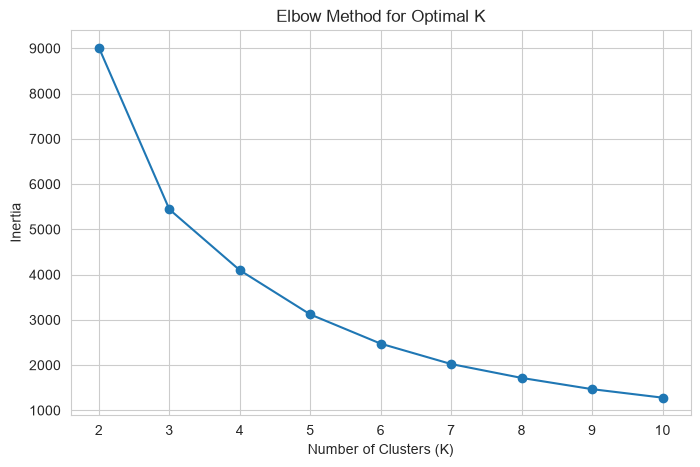

In [22]:
# Elbow Method to find the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [23]:
# Apply K-Means clustering with 3 clusters

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [24]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


In [25]:
# Add customer segment names

cluster_names = {
    0: "At-Risk / Inactive Customers",
    1: "Regular Customers",
    2: "High-Value Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,At-Risk / Inactive Customers
12347.0,2,7,4310.00,1,Regular Customers
12348.0,75,4,1797.24,1,Regular Customers
12349.0,19,1,1757.55,1,Regular Customers
12350.0,310,1,334.40,0,At-Risk / Inactive Customers


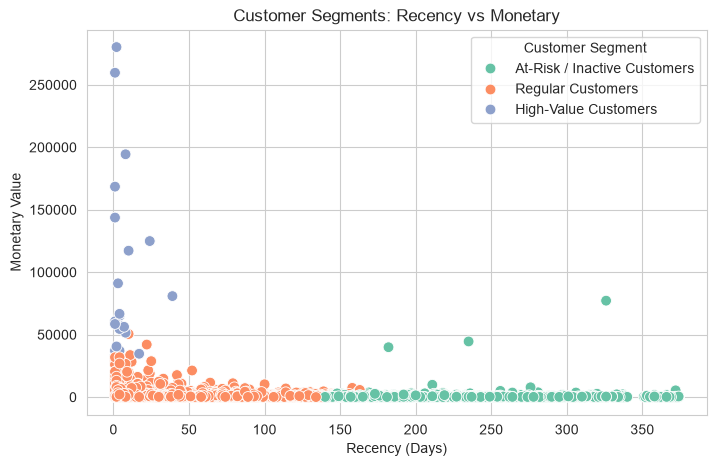

In [26]:
# Scatter plot: Recency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    s=60
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.show()

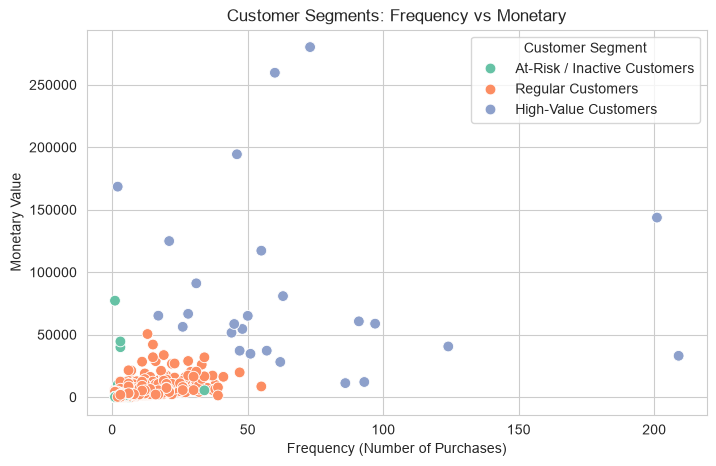

In [27]:
# Scatter plot: Frequency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    s=60
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency (Number of Purchases)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.show()

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings

In [3]:
# Number of customers in each segment

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Segment",
    hue="Segment",
    palette="Set2",
    legend=False
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

NameError: name 'rfm' is not defined

<Figure size 800x500 with 0 Axes>

In [4]:
print("rfm" in globals())


False


In [5]:
%whos

Variable         Type       Data/Info
-------------------------------------
KMeans           ABCMeta    <class 'sklearn.cluster._kmeans.KMeans'>
StandardScaler   type       <class 'sklearn.preproces<...>ng._data.StandardScaler'>
np               module     <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd               module     <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt              module     <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns              module     <module 'seaborn' from 'C<...>s\\seaborn\\__init__.py'>
warnings         module     <module 'warnings' from '<...>on312\\Lib\\warnings.py'>


In [6]:
df = pd.read_excel("Online Retail.xlsx")

df.shape

(541909, 8)

In [7]:
 # Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.shape

(397884, 9)

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [9]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [10]:
rfm.shape

(4338, 3)

In [11]:
print("rfm" in globals())

True


In [12]:
rfm.shape

(4338, 3)

In [13]:
# Select RFM features
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


In [14]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

C:\Users\Afnaa\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Afnaa\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python312\Lib\subprocess.py", line 1538, in _execute_ch

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


In [15]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

In [16]:
cluster_profile = rfm.groupby("Cluster")[features].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,247.11,1.58,631.42
1,41.45,4.67,1855.94
2,6.04,66.42,85904.35


In [17]:
segment_names = {
    0: "At Risk / Inactive",
    1: "Regular Customers",
    2: "High-Value Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,At Risk / Inactive
12347.0,2,7,4310.00,1,Regular Customers
12348.0,75,4,1797.24,1,Regular Customers
12349.0,19,1,1757.55,1,Regular Customers
12350.0,310,1,334.40,0,At Risk / Inactive


In [18]:
rfm["Segment"].value_counts()

Segment
Regular Customers       3230
At Risk / Inactive      1082
High-Value Customers      26
Name: count, dtype: int64

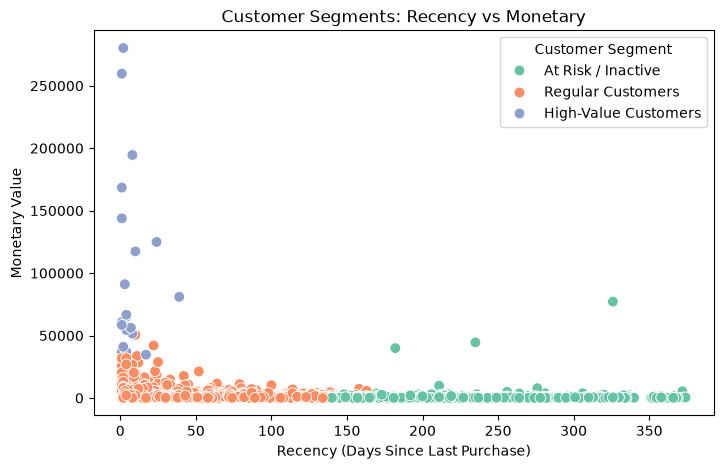

In [19]:
# Scatter plot: Recency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    s=60
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.show()

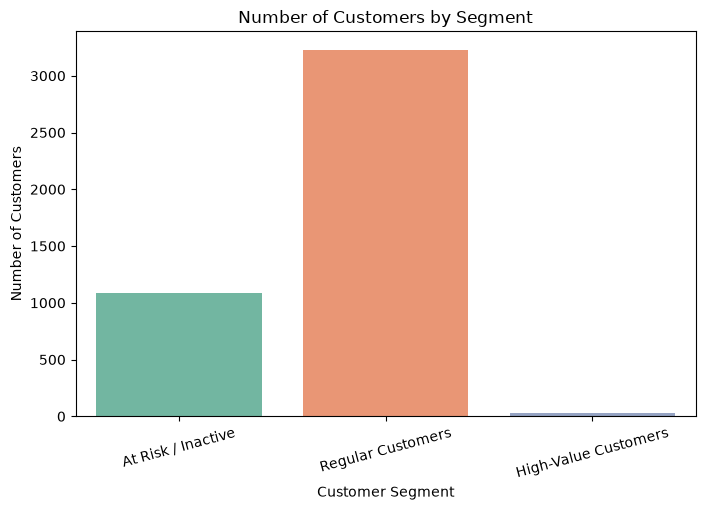

In [20]:
# Number of customers in each segment

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Segment",
    hue="Segment",
    palette="Set2",
    legend=False
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [21]:
cluster_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk / Inactive,247.11,1.58,631.42
High-Value Customers,6.04,66.42,85904.35
Regular Customers,41.45,4.67,1855.94


In [22]:
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)

cluster_profile

,Recency,Frequency,Monetary
Segment,,,
High-Value Customers,6.04,66.42,85904.35
Regular Customers,41.45,4.67,1855.94
At Risk / Inactive,247.11,1.58,631.42


In [24]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Recency", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"] / len(rfm) * 100
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
Segment,,,,,
At Risk / Inactive,1082,247.11,1.58,631.42,24.94
High-Value Customers,26,6.04,66.42,85904.35,0.60
Regular Customers,3230,41.45,4.67,1855.94,74.46


## Key Insights

1. **Regular Customers form the largest segment**, accounting for 74.46% of the customer base. They have an average recency of 41.45 days and an average frequency of 4.67 purchases.

2. **At Risk / Inactive Customers represent 24.94% of customers** and have the highest average recency at 247.11 days, indicating that they have not purchased recently. Their average frequency and monetary value are also relatively low.

3. **High-Value Customers represent only 0.60% of the customer base**, but they show very high purchasing activity, with an average frequency of 66.42 purchases and average monetary value of 85,904.35.

4. The RFM analysis shows clear differences in customer purchasing behaviour, allowing the business to use different marketing strategies for each segment.

5. The largest opportunity is to retain Regular Customers and re-engage At Risk / Inactive Customers while maintaining loyalty among High-Value Customers.

## Marketing Recommendations

### At Risk / Inactive Customers
- Send personalized re-engagement emails.
- Offer limited-time discounts or return incentives.
- Recommend products based on previous purchases.

### Regular Customers
- Encourage more frequent purchases through personalized offers.
- Use cross-selling and product recommendations.
- Introduce loyalty rewards to increase retention.

### High-Value Customers
- Provide VIP or loyalty benefits.
- Offer exclusive products and personalized recommendations.
- Maintain engagement through premium offers and early access to promotions.

In [26]:
print("Total customers:", len(rfm))
print("Total segments:", rfm["Segment"].nunique())
print("\nSegment distribution:")
print(rfm["Segment"].value_counts())

Total customers: 4338
Total segments: 3

Segment distribution:
Segment
Regular Customers       3230
At Risk / Inactive      1082
High-Value Customers      26
Name: count, dtype: int64
